# Multi-Class k-Nearest Neighbour Classification

Uses optimal hyperparameters:
- k: 5
- searchMethod: AUTO
- metric: EUCLIDEAN

In [1]:
import os
import ee
import geemap
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

load_dotenv()
ee.Initialize(project=os.getenv('EE_PROJECT_ID'))

os.makedirs('../../assets', exist_ok=True)

/Users/ashutoshsaxena/Library/Python/3.9/lib/python/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/ashutoshsaxena/Library/Python/3.9/lib/python/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/ashutoshsaxena/Library/Python/3.9/lib/python/site-packages/google/api_core/_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9

In [2]:
campus_geojson = {
    "type": "Polygon",
    "coordinates": [
        [
            [80.01710357666015, 23.173962177472703],
            [80.03259601593017, 23.165361215115187],
            [80.03654422760009, 23.172502420044232],
            [80.026802444458,   23.181694681000845],
            [80.01542987823485, 23.176960548201308],
        ]
    ]
}
campus = ee.Geometry(campus_geojson)

def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud  = 1 << 10
    cirrus = 1 << 11
    mask = qa.bitwiseAnd(cloud).eq(0).And(qa.bitwiseAnd(cirrus).eq(0))
    return image.updateMask(mask).divide(10000)

dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterDate('2026-01-01', '2026-02-28')
      .filterBounds(campus)
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
      .map(mask_s2_clouds)
)
composite = dataset.median().clip(campus)

ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')
ndwi = composite.normalizedDifference(['B3', 'B8']).rename('NDWI')
ndbi = composite.normalizedDifference(['B11', 'B8']).rename('NDBI')
savi = composite.expression(
    '1.5 * (NIR - RED) / (NIR + RED + 0.5)',
    {'NIR': composite.select('B8'), 'RED': composite.select('B4')}
).rename('SAVI')

composite = composite.addBands([ndvi, ndwi, ndbi, savi])
bands = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI', 'SAVI']

In [3]:
water     = ee.FeatureCollection('users/ashutoshsaxena703/water_points')
forest    = ee.FeatureCollection('users/ashutoshsaxena703/forest_points')
soil      = ee.FeatureCollection('users/ashutoshsaxena703/soil_points')
buildings = ee.FeatureCollection('users/ashutoshsaxena703/building_points')

all_points = water.merge(forest).merge(soil).merge(buildings)

training = (
    composite.select(bands)
             .sampleRegions(
                 collection=all_points,
                 properties=['label'],
                 scale=10
             )
             .filter(ee.Filter.notNull(bands + ['label']))
             .randomColumn('random', 42)
)

train_set = training.filter(ee.Filter.lt('random', 0.7))
test_set  = training.filter(ee.Filter.gte('random', 0.7))
print("Train Set Size:", train_set.size().getInfo())
print("Test Set Size:", test_set.size().getInfo())

Train Set Size: 533
Test Set Size: 227


Overall Accuracy: 0.9383259911894273
Kappa Coefficient: 0.9143419314843265


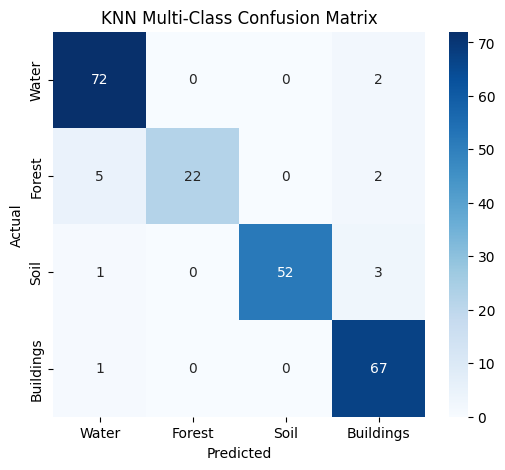

In [4]:
knn_classifier = ee.Classifier.smileKNN(
    k=5,
    searchMethod='AUTO',
    metric='EUCLIDEAN'
).train(
    features=train_set,
    classProperty='label',
    inputProperties=bands
)

test_classified = test_set.classify(knn_classifier)
confusion_matrix = test_classified.errorMatrix('label', 'classification')

print('Overall Accuracy:', confusion_matrix.accuracy().getInfo())
print('Kappa Coefficient:', confusion_matrix.kappa().getInfo())

cm_array = confusion_matrix.array().getInfo()
class_names = ['Water', 'Forest', 'Soil', 'Buildings']

plt.figure(figsize=(6, 5))
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Multi-Class Confusion Matrix')
plt.savefig('../../assets/multi_knn_cm.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
classified = composite.select(bands).classify(knn_classifier)
classified_smooth = classified.focalMode(radius=1, kernelType='square', units='pixels')

class_palette = ['0000FF', '00FF00', 'D2B48C', 'FF0000']

Map = geemap.Map(center=[23.174, 80.026], zoom=15)
Map.addLayer(composite, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'RGB Composite')
Map.addLayer(classified_smooth, {'min': 0, 'max': 3, 'palette': class_palette}, 'KNN Classification')

legend_dict = {
    'Water (0)':      '0000FF',
    'Forest (1)':     '00FF00',
    'Soil (2)':       'D2B48C',
    'Buildings (3)':  'FF0000'
}
Map.add_legend(title='Land Cover', legend_dict=legend_dict)
Map.addLayer(campus, {}, 'Campus Boundary')
Map

Map(center=[23.174, 80.026], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

In [6]:
area_image = ee.Image.pixelArea().addBands(classified_smooth)
areas = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
    geometry=campus,
    scale=10,
    maxPixels=1e10
)

area_data = areas.getInfo()['groups']
print("--- Class Areas (Hectares) ---")
for entry in area_data:
    ha = entry['sum'] / 10000
    print(f"{class_names[entry['class']]}: {ha:.2f} ha")

--- Class Areas (Hectares) ---
Water: 91.66 ha
Forest: 3.81 ha
Soil: 17.27 ha
Buildings: 86.32 ha
